<a href="https://colab.research.google.com/github/MatthewEngel/IT480-FA26/blob/main/Lab2/Lab2_CNN_PetFinder_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *(replace with your name)*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [58]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>

#NOTHING TO BE DONE


In [59]:
# Your imports here


#NOTHING TO BE DONE

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [60]:
# Load train.csv here

#MNIST classification with CNN
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [61]:
# Write your image-loading function here

#Load and preprocess data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

#normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#One hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [62]:
# Build X and y, then split into train/test here

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


*Your written answers for Part A:*

- Image size chosen and why:

MNIST uses the size of 28x28 by default. we have decided to keep this as its whats native and provides enough detail for the CNN to classify.

- Stratification decision and why:
Fashion MNIST is already devided into training and test with balanced representation, the the train/test split already provided is used.


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [63]:
# Build your CNN model here
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    # 10 Fashion-MNIST classes
    Dense(10, activation="softmax")
])


In [64]:
# Compile your model here
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


*Your architecture justification (one paragraph):*

Two Conv2D layers with 32 and 64 filters were used. This increases the filters as the network gets deeper, which futher helps with the learning of more complex features. Each convolution uses a 3x3 kernel as it can detect small local patterns while keeping num of parameters manageable. A MaxPooling2D layer is used after each convolution to reduce spatial dimensions and computations. After this, the layers are funneled into a output layer with 10 neurons for the 10 classes.  


---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [65]:
# Train your model here (save the result as `history`)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.8138 - loss: 0.5056 - val_accuracy: 0.8659 - val_loss: 0.3755
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.8803 - loss: 0.3292 - val_accuracy: 0.8879 - val_loss: 0.3061
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.8967 - loss: 0.2780 - val_accuracy: 0.8957 - val_loss: 0.2873
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9082 - loss: 0.2450 - val_accuracy: 0.9009 - val_loss: 0.2680
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.9183 - loss: 0.2180 - val_accuracy: 0.9063 - val_loss: 0.2559
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9254 - loss: 0.1963 - val_accuracy: 0.9101 - val_loss: 0.2581
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9342 - loss: 0.1749 - val_accuracy: 0.9074 - val_loss: 0.2530
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9418 -

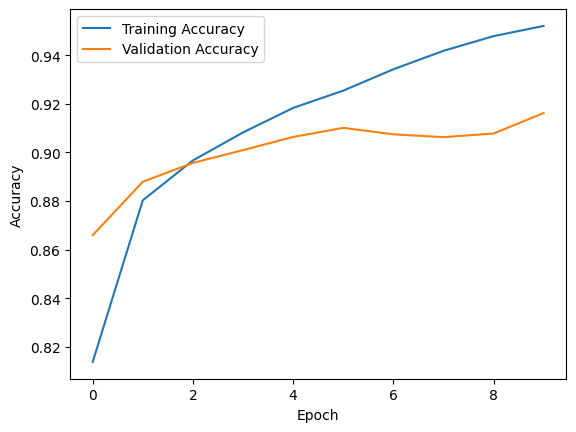

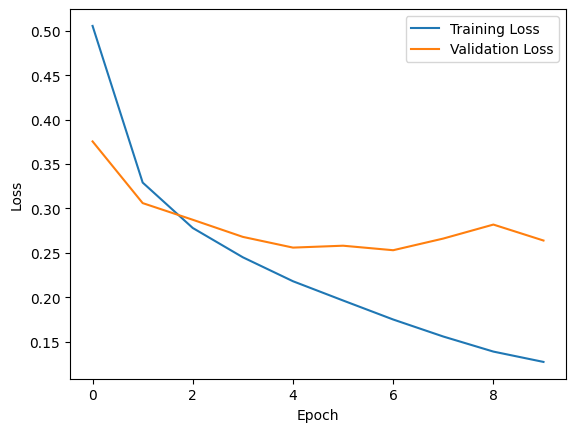

In [66]:
# Plot training vs. validation loss and accuracy here

import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

*Your fit diagnosis, with specific evidence from your curve:*




In [67]:
# Evaluate on the test set and report accuracy here

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9109 - loss: 0.2865
Test loss: 0.28647977113723755
Test accuracy: 0.9108999967575073


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*

I am using Keras Tuner to try to improve the model's accuracy. The baseline CNN achieved a test accuracy of about 90.17%, so I will tune hyperparameters using only the training and validation data to see if a better CNN configuration can be found.


In [68]:
# Build your improved model here
def build_model(hp):
    model = Sequential([
        Conv2D(
            hp.Choice("filters1", [16, 32, 64]),
            (3, 3),
            activation="relu",
            input_shape=(28, 28, 1)
        ),
        MaxPooling2D((2, 2)),

        Conv2D(
            hp.Choice("filters2", [32, 64, 128]),
            (3, 3),
            activation="relu"
        ),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(
            hp.Choice("dense_units", [64, 128, 256]),
            activation="relu"
        ),

        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [70]:
!pip install -q keras-tuner

import keras_tuner as kt
# Train your improved model here
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    directory="tuner_results",
    project_name="fashion_mnist"
)

tuner.search(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)


Trial 5 Complete [00h 09m 18s]
val_accuracy: 0.9150000214576721

Best val_accuracy So Far: 0.9150000214576721
Total elapsed time: 00h 48m 12s


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | 90.17 | 91.08|
| Fit pattern (good/over/under) |good |good |
| What changed |Fixed architecture |Filters and Dense units tuned|

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9100 - loss: 0.2612
Improved CNN Test Accuracy: 0.9100000262260437
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


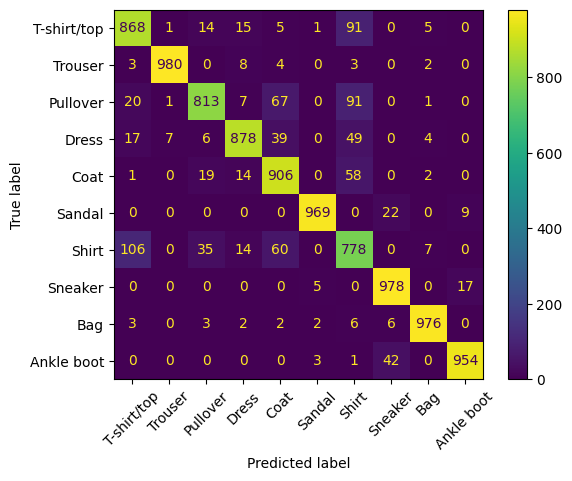

In [71]:
# Evaluate your improved model and build a confusion matrix here

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get best tuned model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on test set
test_loss, improved_accuracy = best_model.evaluate(x_test, y_test)

print("Improved CNN Test Accuracy:", improved_accuracy)

# Make predictions
predictions = best_model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

# Fashion-MNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.show()

*Your discussion of the confusion matrix:*

The improved CNN achieved a test accuracy of about 91.08%, compared with 90.17% for the baseline model. The confusion matrix shows that shirts were the most difficult class for the model, with many shirts being classified as T-shirts/tops, pullovers, or coats. This makes sense because these clothing categories have similar shapes and features in the small 28 × 28 grayscale Fashion-MNIST images.


---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [ ]:
# Find and display misclassified images here



*Your observations about the misclassified images:*




---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.